In [ ]:
"""
This notebook will fit Log Return Volatility vs Sentiment Scores
Goal is to detect regime change 
Use the scikit hidden markov model implementation!

Analysis will only be done for the Information Technology Sector , XLK Ticker
"""

State 0 vs State 1

In [1]:
""" 
In this section I will compare the distribution of the observation in group 0 vs 1 to determine if the differences 
identified by the HMM are significant.
"""
import pandas as pd
df = pd.read_csv("./TickerData/merged_sentiment_ticker.csv")

In [9]:
df

,Date,Information Technology,Health Care,Financials,Consumer Discretionary,Communication Services,Industrials,Consumer Staples,Energy,Utilities,...,XLI Volatility,XLK Closing Price,XLK Log Return,XLK Volatility,XLB Closing Price,XLB Log Return,XLB Volatility,XLRE Closing Price,XLRE Log Return,XLRE Volatility
0,2024-01-22,0.75,0.45,0.25,0.40,0.50,0.20,0.35,0.15,0.10,...,0.010095,99.098984,0.004387,0.011947,39.533054,0.002914,0.006685,36.065884,0.004641,0.010936
1,2024-01-23,0.62,0.18,0.74,0.56,0.68,0.31,0.12,-0.08,0.05,...,0.007876,99.498222,0.004021,0.011758,39.662483,0.003269,0.004518,35.871078,-0.005416,0.010898
2,2024-01-24,0.45,0.22,0.33,0.32,0.44,0.37,0.18,0.41,0.29,...,0.007679,100.183365,0.006862,0.009070,39.125599,-0.013629,0.007310,35.379444,-0.013800,0.009348
3,2024-01-24,0.84,0.05,0.08,0.48,0.82,0.14,0.12,-0.18,0.02,...,0.007679,100.183365,0.006862,0.009070,39.125599,-0.013629,0.007310,35.379444,-0.013800,0.009348
4,2024-01-25,0.20,0.08,0.18,-0.08,0.12,-0.22,0.02,0.15,0.04,...,0.006631,100.602348,0.004173,0.008101,39.537849,0.010481,0.008839,35.861801,0.013542,0.011206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
511,2026-03-16,0.15,0.05,-0.35,-0.10,0.10,-0.15,0.05,0.85,0.00,...,0.012263,138.607666,0.014370,0.012484,49.181286,0.004260,0.005100,42.295715,0.007780,0.007673
512,2026-03-17,0.55,0.10,-0.20,0.35,0.25,-0.05,-0.10,0.75,-0.05,...,0.012842,139.366714,0.005461,0.012870,49.300755,0.002426,0.005540,42.434780,0.003283,0.008022
513,2026-03-18,0.20,-0.05,-0.15,-0.10,0.15,0.10,-0.35,0.85,-0.05,...,0.012924,137.788681,-0.011387,0.013294,48.265358,-0.021225,0.010369,41.739452,-0.016522,0.009680
514,2026-03-18,-0.10,-0.05,-0.20,-0.35,-0.05,-0.25,-0.15,0.65,-0.15,...,0.012924,137.788681,-0.011387,0.013294,48.265358,-0.021225,0.010369,41.739452,-0.016522,0.009680


In [10]:
""" 
Will be training using a 3 month window and testing on the proceeding 3 months
"""
import numpy as np
batches = np.array_split(df.loc[:,["Date","Information Technology", "XLK Volatility"]], 10)
train_batches = []
test_batches = []

for i in range(len(batches)):
    if i % 2 == 0:
        train_batches.append(batches[i])
        print(f"Train batch len: {len(batches[i])}")
    else:
        test_batches.append(batches[i])
        print(f"Test batch len: {len(batches[i])}")



Train batch len: 52
Test batch len: 52
Train batch len: 52
Test batch len: 52
Train batch len: 52
Test batch len: 52
Train batch len: 51
Test batch len: 51
Train batch len: 51
Test batch len: 51


In [6]:
from Hidden_Markov_Model import HMM_Pipeline

num_of_regimes = 2
n_mix = 2
hmm_pipeline = HMM_Pipeline(num_of_regimes, n_mix)

In [ ]:
from scipy import stats
sector = "Information Technology"
ticker = "XLK"
num_of_iters = 100

t_stat_lst = [] #List of tuples (tstat for sentiment score between grps, tstat for volatility between grps)
p_val_lst = [] #List of tuples corresponding to above tstats

for i in range(5):
    print(f"\n********Results of Batch {i}******************\n")
    results_df = hmm_pipeline.HMM_pipeline(sector, ticker, train_batches[i], test_batches[i], num_of_iters)

    #Compute T-tests
    t_stat1, p_val1 = stats.ttest_ind(results_df.loc[results_df["Predicted States"] == 0, [f"{ticker} Volatility"]],results_df.loc[results_df["Predicted States"] == 1, [f"{ticker} Volatility"]])
    t_stat2, p_val2 = stats.ttest_ind(results_df.loc[results_df["Predicted States"] == 0, [sector]],results_df.loc[results_df["Predicted States"] == 1, [sector]])
    t_stat_lst.append((t_stat2, t_stat1))
    p_val_lst.append((p_val2, p_val1))

********Results of Batch 0******************


  State 0 Sentiment Score  (n=34)

Means:
Information Technology    0.407647
XLK Volatility            0.010818

Covariance Matrix:
                        Information Technology  XLK Volatility
Information Technology                0.065037       -0.000275
XLK Volatility                       -0.000275        0.000016

Correlation Matrix:
                        Information Technology  XLK Volatility
Information Technology                1.000000       -0.273129
XLK Volatility                       -0.273129        1.000000

  State 1 Sentiment Score  (n=18)

Means:
Information Technology    0.231667
XLK Volatility            0.012697

Covariance Matrix:
                        Information Technology  XLK Volatility
Information Technology                0.113885       -0.000435
XLK Volatility                       -0.000435        0.000009

Correlation Matrix:
                        Information Technology  XLK Volatility
Information Tech

In [ ]:
""" 
Analysis of Means and Correlation Matrix

Batch 0:
- For both states sentiment score and return volatility appear to be neg. correlated to eachother
This is suprising. Distinction between states was made by the magnitude not trend.

Batch 1:
-State 0 showed approx nuetral correlation between sentiment and return vol
State 1 showed positive correlation between sentiment and return vol

Batch 2:
-State 0 and 1 showed almost neutral correlation between sentiment and return vol.

Batch 3:
-State 0 had positive correlation between sentimenet score and return vol 
State 1 had approx neutral

Batch 4:
-State 0 negative correlation between sentiment scores and return vol
Note 0 observations classified as state 1.
"""

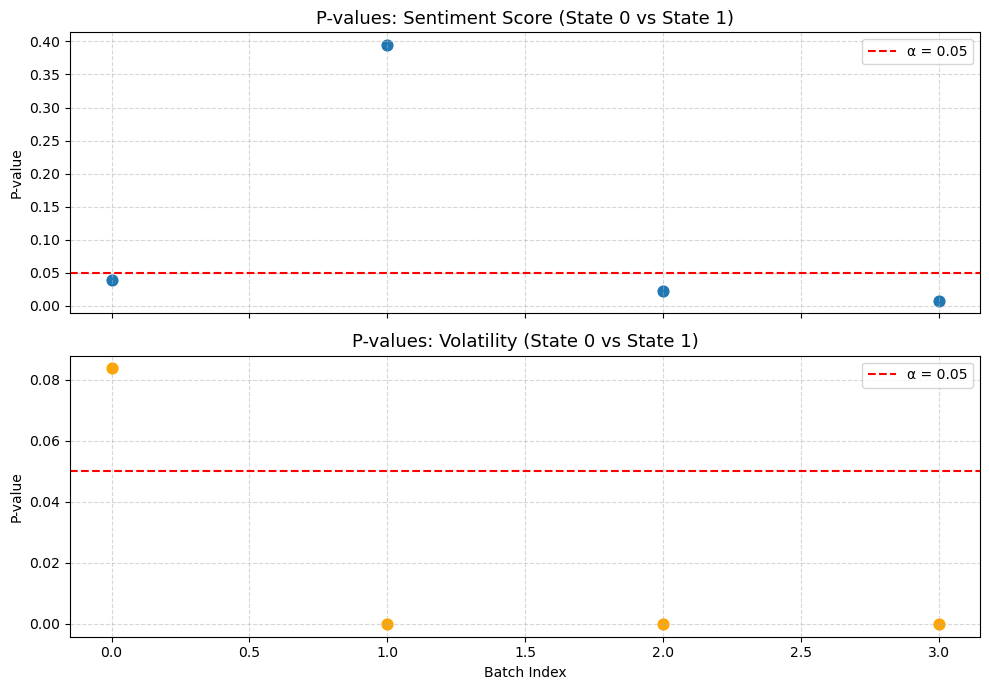

In [18]:
import numpy as np
import matplotlib.pyplot as plt

lst1 = [tup[0] for tup in p_val_lst]
lst2 = [tup[1] for tup in p_val_lst]

x = np.arange(len(lst1))

fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# ---- Plot 1: Sentiment ----
ax[0].scatter(x, lst1, s=60)
ax[0].axhline(y=0.05, color='red', linestyle='--', linewidth=1.5, label='α = 0.05')
ax[0].set_title("P-values: Sentiment Score (State 0 vs State 1)", fontsize=13)
ax[0].set_ylabel("P-value")
ax[0].grid(True, linestyle='--', alpha=0.5)
ax[0].legend()

# ---- Plot 2: Volatility ----
ax[1].scatter(x, lst2, s=60, color='orange')
ax[1].axhline(y=0.05, color='red', linestyle='--', linewidth=1.5, label='α = 0.05')
ax[1].set_title("P-values: Volatility (State 0 vs State 1)", fontsize=13)
ax[1].set_xlabel("Batch Index")
ax[1].set_ylabel("P-value")
ax[1].grid(True, linestyle='--', alpha=0.5)
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
""" 
Analysis:
Differences in distribution of sentiment scores and volatility of returns were significantly different between
State 0 and 1. 

It can be observed that the distinction appears to be more apparent for the volatility of the return of the 2 groups

Note: Due to limited data only 5 batches
- Batch 4: Had 0 State 1 classifications
- Batch 0: Had 6 State 1 classifications

Rest of the batches had more even splits of classifications

These uneven split is not necessarily a sign of weakness of the model, note their is a time component that 
influences classification splits. It could be during Batch 4 and 0 market behaved typically 
and moved with sentiment scores!!

"""

In [5]:
hmm_pipeline._Visualize_Results(results_df, sector, ticker)

In [ ]:
""" 
Questions about length of training data set and how frequently the model should be retrained
These questions are more difficult to answer and I feel require domain knowledge!!
"""

In [ ]:
""" 
Summary:

The goal of this exploration was to determine if we can study market participant's sensitivity to news. This was 
attempted by looking at sentiment scores obtained from Bloomberg Survillance new transcripts and 
return volatilities of specific SP500 sectors (Tech, Energy, etc). LLM Gemini was fed webscrapped transcripts to provide contextualized sentiment score related to 
specific market sectors. Data was split into 5 train-test batches and fed to a hidden markov model. The intention was to identify a state where the sentiment scores 
and the return volatilies were positively correlated and another state where they were negatively correlated. Final results were inconclusive, two batches showed states with
distinct correlation trends, 2 batches showed similar correlation trends for both states, the final batch showed all observation belonged to one state.

T-tests were used to compare the observations in groups 1 versus 2. For 3 out of 4 batches the differences were significant however these significant differences may or may not be due to the 
limited data size when computing statisitcs.
"""